In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
dfMTQ = pd.read_csv('cells_MTQ.csv', index_col=0)
dfMNG = pd.read_csv('cells_MNG.csv', index_col=0)
df = pd.concat([dfMTQ, dfMNG], ignore_index=True)

In [3]:
#Garbage filters

df = df[df['circ_cell_original'] < 0.8]
df = df[df['circ_cell_original'] > 0.3]
df = df[df['area_cell_original'] > 2000]
df = df[df['area_cell_original'] < 25000]

df = df[df['area_nuc'] < 5000]
df = df[df['area_nuc'] > 600]

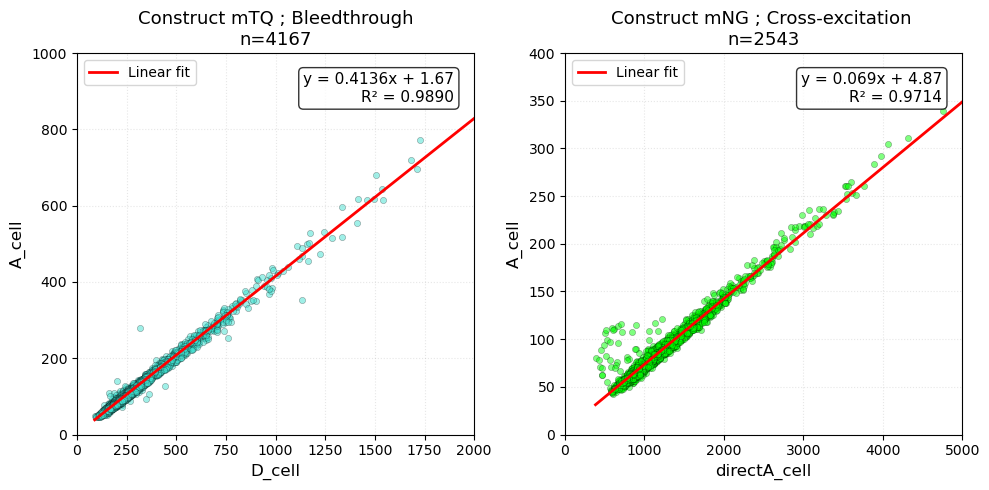

In [4]:
# Create figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# MTQ plot (left)
mtq_df = df[df['construct'] == 'MTQ']
mtq_clean = mtq_df[['D_cell', 'A_cell']].dropna()
slope_mtq, intercept_mtq, r_value_mtq, p_value_mtq, std_err_mtq = stats.linregress(mtq_clean['D_cell'], mtq_clean['A_cell'])

ax[0].scatter(mtq_df['D_cell'], mtq_df['A_cell'], 
              alpha=0.5, s=20, color='turquoise', edgecolors='black', linewidth=0.3)

x_line_mtq = np.linspace(mtq_df['D_cell'].min(), mtq_df['D_cell'].max(), 100)
y_line_mtq = slope_mtq * x_line_mtq + intercept_mtq
ax[0].plot(x_line_mtq, y_line_mtq, color='red', linewidth=2, label='Linear fit')

formula_text_mtq = f'y = {slope_mtq:.4f}x + {intercept_mtq:.2f}\nR² = {r_value_mtq**2:.4f}'
ax[0].text(0.95, 0.95, formula_text_mtq, transform=ax[0].transAxes,
           fontsize=11, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[0].set_xlim(0, 2000)
ax[0].set_ylim(0, 1000)
ax[0].set_xlabel('D_cell', fontsize=12)
ax[0].set_ylabel('A_cell', fontsize=12)
ax[0].set_title(f'Construct mTQ ; Bleedthrough\nn={len(mtq_df)}', 
                fontsize=13)
ax[0].grid(True, linestyle=':', alpha=0.3)
ax[0].legend(loc='upper left', fontsize=10)

# MNG plot (right)
mng_df = df[df['construct'] == 'MNG']
mng_clean = mng_df[['directA_cell', 'A_cell']].dropna()
slope_mng, intercept_mng, r_value_mng, p_value_mng, std_err_mng = stats.linregress(mng_clean['directA_cell'], mng_clean['A_cell'])

ax[1].scatter(mng_df['directA_cell'], mng_df['A_cell'], 
              alpha=0.5, s=20, color='lime', edgecolors='black', linewidth=0.3)

x_line_mng = np.linspace(mng_df['directA_cell'].min(), mng_df['directA_cell'].max(), 100)
y_line_mng = slope_mng * x_line_mng + intercept_mng
ax[1].plot(x_line_mng, y_line_mng, color='red', linewidth=2, label='Linear fit')

formula_text_mng = f'y = {slope_mng:.3f}x + {intercept_mng:.2f}\nR² = {r_value_mng**2:.4f}'
ax[1].text(0.95, 0.95, formula_text_mng, transform=ax[1].transAxes,
           fontsize=11, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].set_xlim(0, 5000)
ax[1].set_ylim(0, 400)
ax[1].set_xlabel('directA_cell', fontsize=12)
ax[1].set_ylabel('A_cell', fontsize=12)
ax[1].set_title(f'Construct mNG ; Cross-excitation \nn={len(mng_df)}', 
                fontsize=13)
ax[1].grid(True, linestyle=':', alpha=0.3)
ax[1].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('Figure_graphs/FigSI/ArtifactCorrections.svg')